# VC API Scoring — Calibration Diagnostics

Compare Claude API VC predictions (46 GT images) against ground truth.  
Goal: diagnose bias, range compression, rank-order accuracy, and per-dimension patterns.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

In [2]:
# ── Load data ───────────────────────────────────────────────────────
gt = pd.read_csv('gt_all_46.csv')
pred = pd.read_csv('../vc_api_46gt/vc_scores.csv')
expl = pd.read_csv('../vc_api_46gt/vc_explanations.csv')

# Merge
df = gt.merge(pred, left_on='imageName', right_on='filename', how='inner')
print(f'Matched: {len(df)} / {len(gt)} images')
df.head()

Matched: 46 / 46 images


,imageName,NormalizedVC,filename,data_density,visual_encoding,text_annotation,domain_schema,color_symbol,aesthetic_order,cognitive_load,vc_score
0,wsj135.png,0.35,wsj135.png,0.35,0.25,0.45,0.20,0.25,0.15,0.20,0.26
1,SciVisJ.1025.11.png,0.36,SciVisJ.1025.11.png,0.35,0.30,0.45,0.40,0.40,0.25,0.35,0.35
2,visMost97.png,0.38,visMost97.png,0.15,0.25,0.30,0.15,0.35,0.10,0.15,0.20
3,economist_daily_chart_165.png,0.43,economist_daily_chart_165.png,0.50,0.30,0.40,0.20,0.25,0.20,0.30,0.31
4,whoO06_2.png,0.45,whoO06_2.png,0.65,0.40,0.55,0.45,0.35,0.20,0.45,0.44


## 1. Overall vc_score vs Ground Truth

In [3]:
# ── Key metrics ─────────────────────────────────────────────────────
gt_vc = df['NormalizedVC'].values
pred_vc = df['vc_score'].values

pearson_r, pearson_p = stats.pearsonr(gt_vc, pred_vc)
spearman_r, spearman_p = stats.spearmanr(gt_vc, pred_vc)
mae = mean_absolute_error(gt_vc, pred_vc)
rmse = np.sqrt(mean_squared_error(gt_vc, pred_vc))
bias = np.mean(pred_vc - gt_vc)
r2 = r2_score(gt_vc, pred_vc)

print('=== Overall vc_score Metrics ===')
print(f'Pearson r:   {pearson_r:.3f}  (p={pearson_p:.2e})')
print(f'Spearman ρ:  {spearman_r:.3f}  (p={spearman_p:.2e})')
print(f'R²:          {r2:.3f}')
print(f'MAE:         {mae:.3f}')
print(f'RMSE:        {rmse:.3f}')
print(f'Bias:        {bias:+.3f}  ({"underestimates" if bias < 0 else "overestimates"})')
print(f'Pred range:  [{pred_vc.min():.2f}, {pred_vc.max():.2f}]')
print(f'GT range:    [{gt_vc.min():.2f}, {gt_vc.max():.2f}]')

=== Overall vc_score Metrics ===
Pearson r:   0.904  (p=7.67e-18)
Spearman ρ:  0.891  (p=1.19e-16)
R²:          0.561
MAE:         0.097
RMSE:        0.121
Bias:        -0.085  (underestimates)
Pred range:  [0.14, 0.85]
GT range:    [0.22, 0.95]


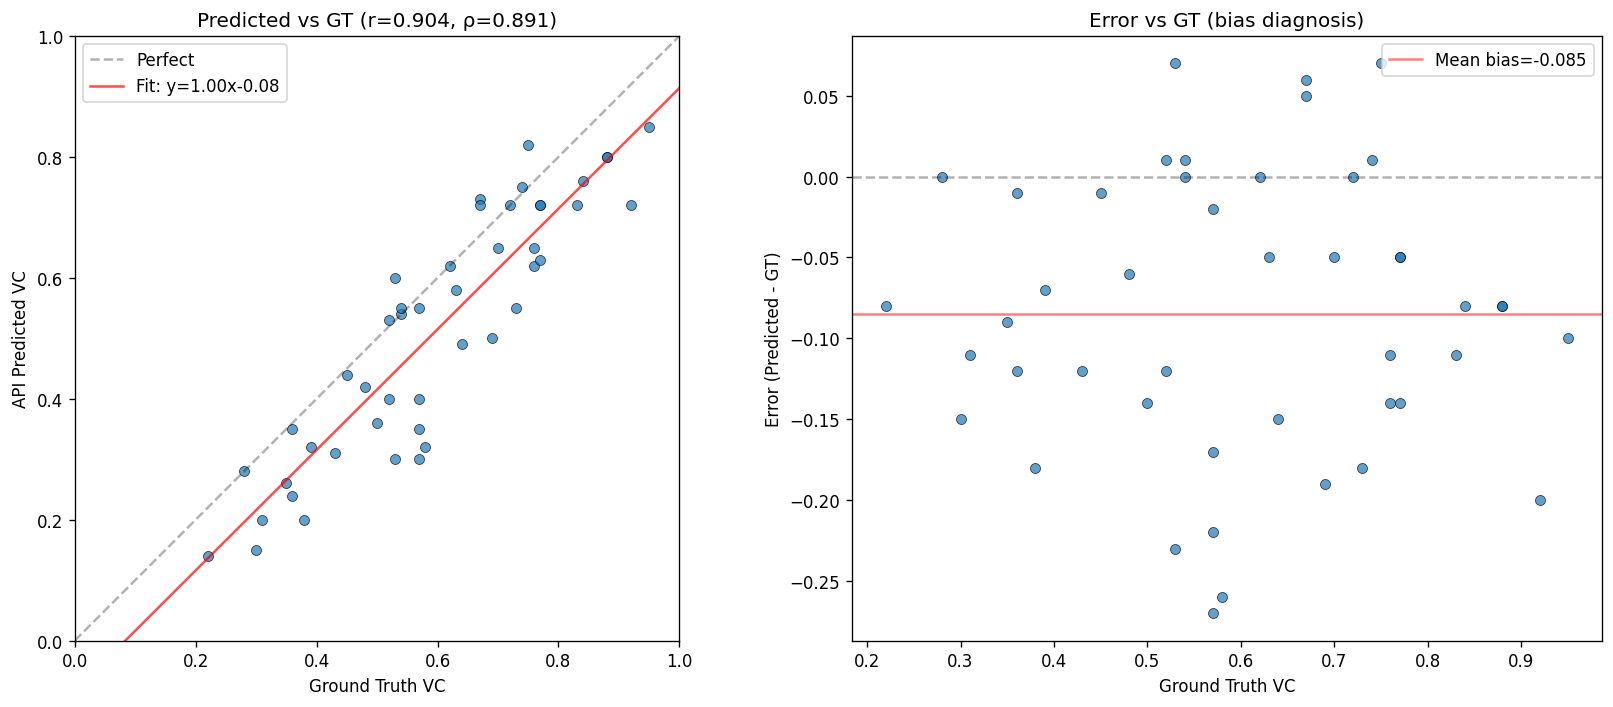

In [4]:
# ── Scatter: Predicted vs GT ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: raw scatter with regression
ax = axes[0]
ax.scatter(gt_vc, pred_vc, alpha=0.7, edgecolors='k', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect')

# Regression line
slope, intercept = np.polyfit(gt_vc, pred_vc, 1)
x_fit = np.linspace(0, 1, 100)
ax.plot(x_fit, slope * x_fit + intercept, 'r-', alpha=0.7,
        label=f'Fit: y={slope:.2f}x{intercept:+.2f}')
ax.set_xlabel('Ground Truth VC')
ax.set_ylabel('API Predicted VC')
ax.set_title(f'Predicted vs GT (r={pearson_r:.3f}, ρ={spearman_r:.3f})')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')

# Right: error vs GT (bias pattern)
ax = axes[1]
errors = pred_vc - gt_vc
ax.scatter(gt_vc, errors, alpha=0.7, edgecolors='k', linewidth=0.5)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.axhline(bias, color='r', linestyle='-', alpha=0.5, label=f'Mean bias={bias:+.3f}')
ax.set_xlabel('Ground Truth VC')
ax.set_ylabel('Error (Predicted - GT)')
ax.set_title('Error vs GT (bias diagnosis)')
ax.legend()

plt.tight_layout()
plt.savefig('../vc_api_46gt/calibration_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Range & Distribution Comparison

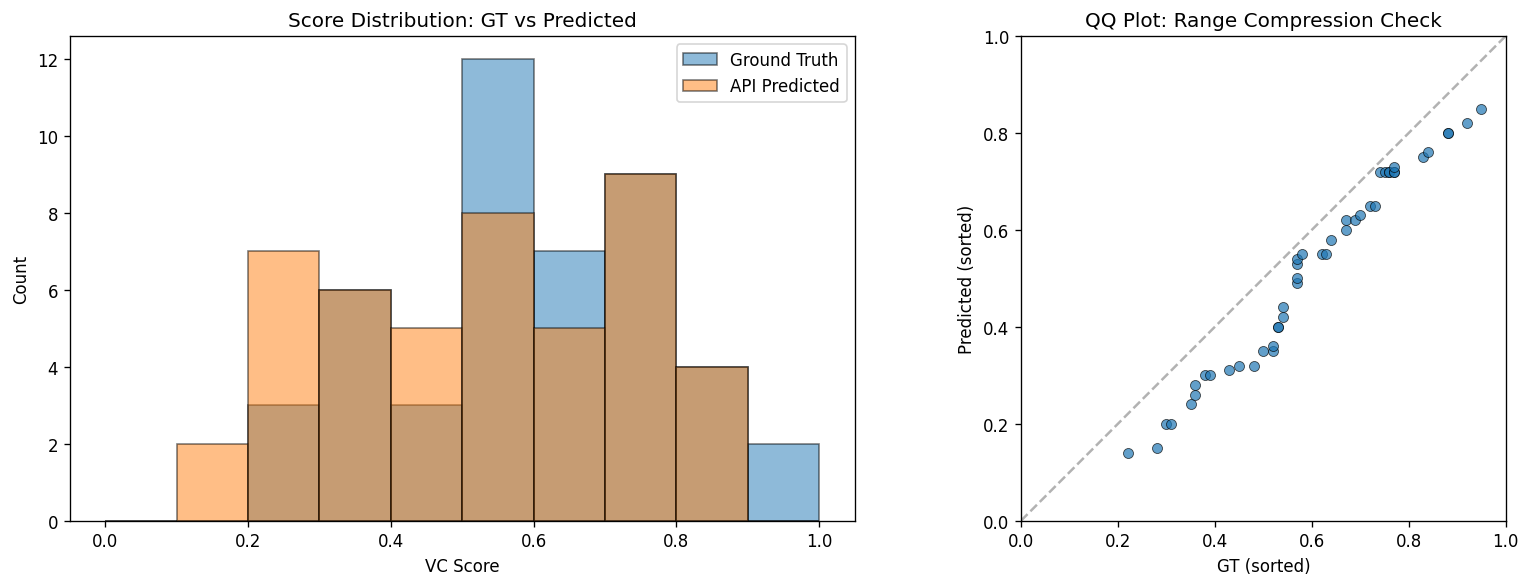

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax = axes[0]
bins = np.arange(0, 1.05, 0.1)
ax.hist(gt_vc, bins=bins, alpha=0.5, label='Ground Truth', edgecolor='black')
ax.hist(pred_vc, bins=bins, alpha=0.5, label='API Predicted', edgecolor='black')
ax.set_xlabel('VC Score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution: GT vs Predicted')
ax.legend()

# QQ-style: sorted GT vs sorted pred
ax = axes[1]
gt_sorted = np.sort(gt_vc)
pred_sorted = np.sort(pred_vc)
ax.scatter(gt_sorted, pred_sorted, alpha=0.7, edgecolors='k', linewidth=0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('GT (sorted)')
ax.set_ylabel('Predicted (sorted)')
ax.set_title('QQ Plot: Range Compression Check')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../vc_api_46gt/range_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Image Error Bars (sorted by GT)

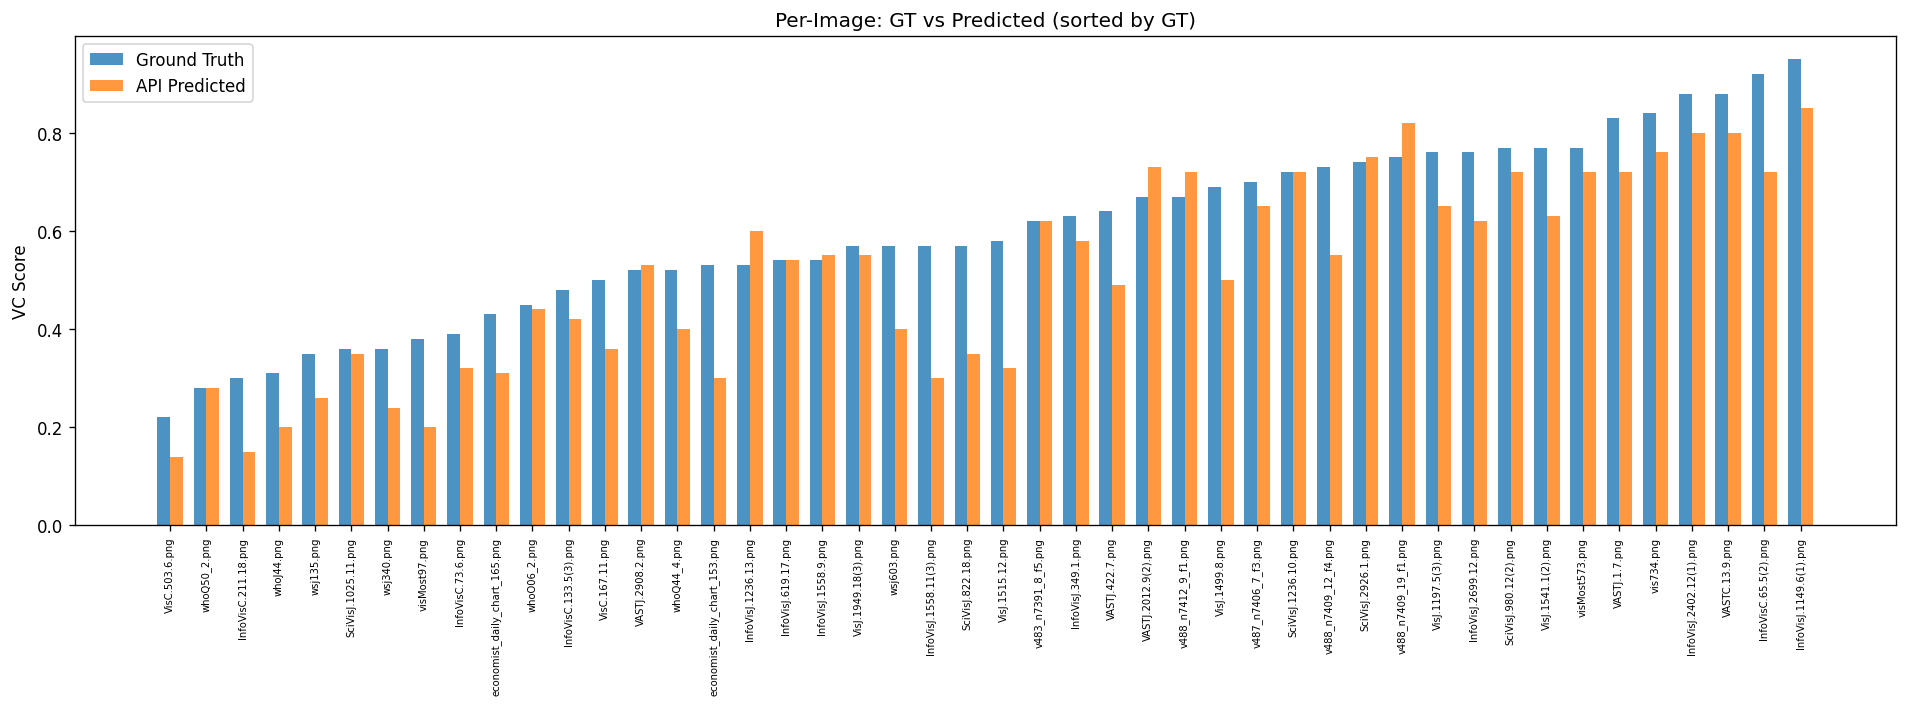

In [6]:
df_sorted = df.sort_values('NormalizedVC').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(df_sorted))
w = 0.35
ax.bar(x - w/2, df_sorted['NormalizedVC'], w, label='Ground Truth', alpha=0.8)
ax.bar(x + w/2, df_sorted['vc_score'], w, label='API Predicted', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted['imageName'], rotation=90, fontsize=6)
ax.set_ylabel('VC Score')
ax.set_title('Per-Image: GT vs Predicted (sorted by GT)')
ax.legend()
plt.tight_layout()
plt.savefig('../vc_api_46gt/per_image_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-Dimension Analysis

In [7]:
DIMS = ['data_density', 'visual_encoding', 'text_annotation',
        'domain_schema', 'color_symbol', 'aesthetic_order', 'cognitive_load']

dim_stats = []
for dim in DIMS:
    vals = df[dim].values
    r_val, _ = stats.pearsonr(gt_vc, vals)
    rho_val, _ = stats.spearmanr(gt_vc, vals)
    dim_stats.append({
        'Dimension': dim,
        'Mean': vals.mean(),
        'Std': vals.std(),
        'Min': vals.min(),
        'Max': vals.max(),
        'Pearson_r_vs_GT': r_val,
        'Spearman_ρ_vs_GT': rho_val
    })

dim_df = pd.DataFrame(dim_stats)
print(dim_df.to_string(index=False, float_format='%.3f'))

      Dimension  Mean   Std   Min   Max  Pearson_r_vs_GT  Spearman_ρ_vs_GT
   data_density 0.583 0.229 0.120 0.920            0.872             0.865
visual_encoding 0.545 0.225 0.120 0.900            0.887             0.882
text_annotation 0.374 0.243 0.000 0.850            0.070            -0.030
  domain_schema 0.561 0.241 0.150 0.920            0.841             0.832
   color_symbol 0.463 0.213 0.050 0.850            0.637             0.618
aesthetic_order 0.385 0.198 0.100 0.800            0.812             0.824
 cognitive_load 0.555 0.234 0.100 0.920            0.903             0.897


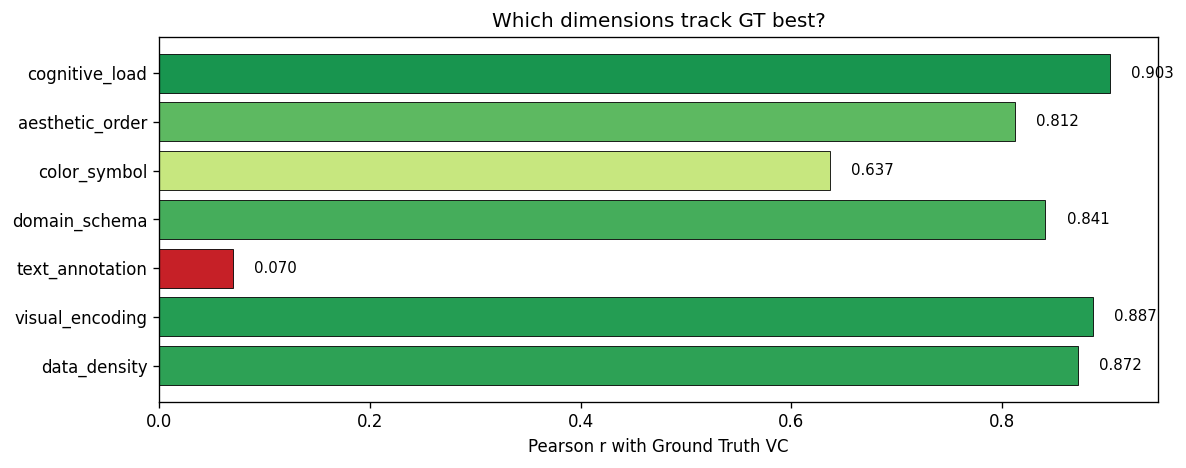

In [8]:
# ── Dimension correlation with GT heatmap ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
corr_vals = dim_df['Pearson_r_vs_GT'].values
colors = plt.cm.RdYlGn(corr_vals)  # green=high correlation
bars = ax.barh(dim_df['Dimension'], corr_vals, color=colors, edgecolor='k', linewidth=0.5)
ax.set_xlabel('Pearson r with Ground Truth VC')
ax.set_title('Which dimensions track GT best?')
ax.axvline(0, color='k', linewidth=0.5)
for bar, val in zip(bars, corr_vals):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../vc_api_46gt/dimension_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Error Pattern Diagnosis

In [9]:
# ── Classify error pattern ──────────────────────────────────────────
errors = pred_vc - gt_vc

# Bias test
t_stat, t_p = stats.ttest_1samp(errors, 0)
print(f'Bias test (H0: mean error = 0): t={t_stat:.2f}, p={t_p:.4f}')
print(f'  → {"Significant bias" if t_p < 0.05 else "No significant bias"}')
print()

# Range compression: regression slope
print(f'Regression slope: {slope:.3f}  (1.0 = perfect scale, <1 = compressed)')
print(f'Regression intercept: {intercept:+.3f}')
print()

# Error by GT tercile
df['gt_tercile'] = pd.qcut(df['NormalizedVC'], 3, labels=['Low', 'Mid', 'High'])
df['error'] = df['vc_score'] - df['NormalizedVC']
tercile_stats = df.groupby('gt_tercile')['error'].agg(['mean', 'std', 'count'])
print('Error by GT tercile:')
print(tercile_stats.to_string(float_format='%.3f'))
print()

# Worst predictions
df['abs_error'] = df['error'].abs()
print('Top 5 worst predictions:')
worst = df.nlargest(5, 'abs_error')[['imageName', 'NormalizedVC', 'vc_score', 'error']]
print(worst.to_string(index=False, float_format='%.3f'))

Bias test (H0: mean error = 0): t=-6.62, p=0.0000
  → Significant bias

Regression slope: 0.997  (1.0 = perfect scale, <1 = compressed)
Regression intercept: -0.083

Error by GT tercile:
             mean   std  count
gt_tercile                    
Low        -0.083 0.077     17
Mid        -0.090 0.116     14
High       -0.083 0.072     15

Top 5 worst predictions:
                    imageName  NormalizedVC  vc_score  error
      InfoVisJ.1558.11(3).png         0.570     0.300 -0.270
             VisJ.1515.12.png         0.580     0.320 -0.260
economist_daily_chart_153.png         0.530     0.300 -0.230
           SciVisJ.822.18.png         0.570     0.350 -0.220
         InfoVisC.65.5(2).png         0.920     0.720 -0.200


## 6. Linear Recalibration (train/test split)

In [10]:
# ── Train/test split for calibration ───────────────────────────────
np.random.seed(42)
train_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.35, random_state=42)

train = df.iloc[train_idx]
test = df.iloc[test_idx]
print(f'Train: {len(train)} images, Test: {len(test)} images')

# Fit linear calibration on train
cal_slope, cal_intercept = np.polyfit(train['vc_score'], train['NormalizedVC'], 1)
print(f'Calibration: GT_est = {cal_slope:.3f} * pred {cal_intercept:+.3f}')

# Apply to test
test_calibrated = cal_slope * test['vc_score'] + cal_intercept
test_raw = test['vc_score'].values
test_gt = test['NormalizedVC'].values

# Metrics: raw vs calibrated on TEST set
print(f'\n{"Metric":<15} {"Raw":>8} {"Calibrated":>12}')
print('-' * 37)

r_raw, _ = stats.pearsonr(test_gt, test_raw)
r_cal, _ = stats.pearsonr(test_gt, test_calibrated)
print(f'{"Pearson r":<15} {r_raw:>8.3f} {r_cal:>12.3f}')

rho_raw, _ = stats.spearmanr(test_gt, test_raw)
rho_cal, _ = stats.spearmanr(test_gt, test_calibrated)
print(f'{"Spearman ρ":<15} {rho_raw:>8.3f} {rho_cal:>12.3f}')

mae_raw = mean_absolute_error(test_gt, test_raw)
mae_cal = mean_absolute_error(test_gt, test_calibrated)
print(f'{"MAE":<15} {mae_raw:>8.3f} {mae_cal:>12.3f}')

rmse_raw = np.sqrt(mean_squared_error(test_gt, test_raw))
rmse_cal = np.sqrt(mean_squared_error(test_gt, test_calibrated))
print(f'{"RMSE":<15} {rmse_raw:>8.3f} {rmse_cal:>12.3f}')

bias_raw = np.mean(test_raw - test_gt)
bias_cal = np.mean(test_calibrated - test_gt)
print(f'{"Bias":<15} {bias_raw:>+8.3f} {bias_cal:>+12.3f}')

Train: 29 images, Test: 17 images
Calibration: GT_est = 0.800 * pred +0.170

Metric               Raw   Calibrated
-------------------------------------
Pearson r          0.914        0.914
Spearman ρ         0.854        0.854
MAE                0.119        0.071
RMSE               0.137        0.087
Bias              -0.112       -0.048


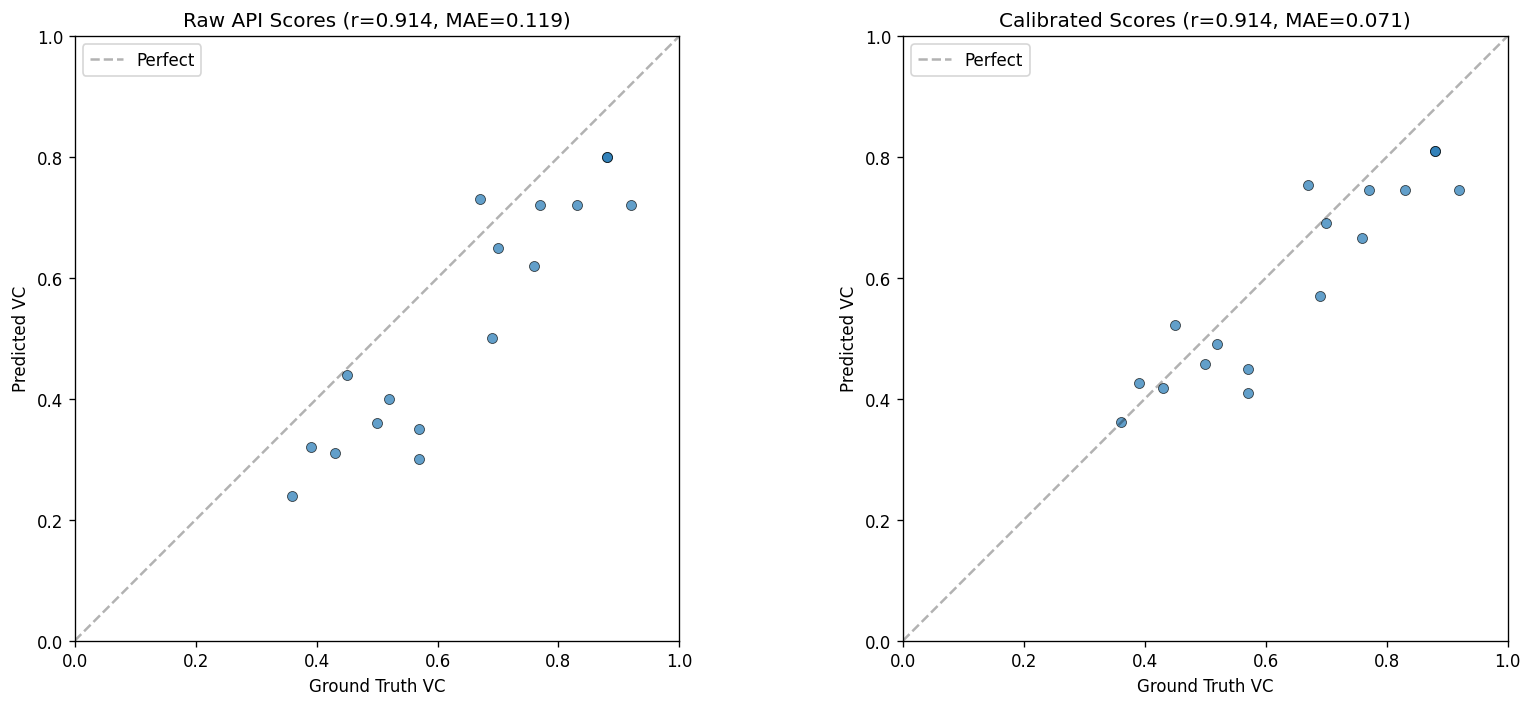

In [11]:
# ── Scatter: raw vs calibrated on test set ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, vals, title in [(axes[0], test_raw, 'Raw API Scores'),
                         (axes[1], test_calibrated, 'Calibrated Scores')]:
    ax.scatter(test_gt, vals, alpha=0.7, edgecolors='k', linewidth=0.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect')
    r_val, _ = stats.pearsonr(test_gt, vals)
    m_val = mean_absolute_error(test_gt, vals)
    ax.set_title(f'{title} (r={r_val:.3f}, MAE={m_val:.3f})')
    ax.set_xlabel('Ground Truth VC')
    ax.set_ylabel('Predicted VC')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.legend()

plt.tight_layout()
plt.savefig('../vc_api_46gt/calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary & Recommendations

In [12]:
print('=== DIAGNOSIS SUMMARY ===')
print()
if abs(bias) > 0.1:
    direction = 'low' if bias < 0 else 'high'
    print(f'⚠ CONSTANT BIAS: Model scores {direction} by {abs(bias):.2f} on average')
    print(f'  → Fix: Adjust anchor scores or add range guidance in prompt')
else:
    print(f'✓ Bias is small ({bias:+.3f})')
print()

if slope < 0.7:
    print(f'⚠ RANGE COMPRESSION: slope={slope:.2f} (pred range much narrower than GT)')
    print(f'  → Fix: Widen anchor gap, add "use full 0-1 range" instruction')
elif slope < 0.85:
    print(f'⚠ MILD RANGE COMPRESSION: slope={slope:.2f}')
    print(f'  → Fix: Post-hoc linear recalibration may suffice')
else:
    print(f'✓ Range scaling OK (slope={slope:.2f})')
print()

if pearson_r > 0.8:
    print(f'✓ STRONG correlation (r={pearson_r:.3f}) — rank order is good')
elif pearson_r > 0.6:
    print(f'~ MODERATE correlation (r={pearson_r:.3f}) — usable but room for improvement')
else:
    print(f'⚠ WEAK correlation (r={pearson_r:.3f}) — prompt needs rework')
print()

print(f'Spearman ρ = {spearman_r:.3f} (rank correlation)')
print(f'MAE after linear calibration (test set): {mae_cal:.3f}')

=== DIAGNOSIS SUMMARY ===

✓ Bias is small (-0.085)

✓ Range scaling OK (slope=1.00)

✓ STRONG correlation (r=0.904) — rank order is good

Spearman ρ = 0.891 (rank correlation)
MAE after linear calibration (test set): 0.071


## V1 vs V2 Prompt Comparison

In [13]:
# ── Load V2 scores and compare with V1 ──
pred_v2 = pd.read_csv('../vc_api_46gt_v2/vc_scores.csv')
df_v2 = gt.merge(pred_v2, left_on='imageName', right_on='filename', how='inner')
print(f'V2 matched: {len(df_v2)} / {len(gt)} images')

gt_vc2 = df_v2['NormalizedVC'].values
pred_vc2 = df_v2['vc_score'].values

from scipy.stats import pearsonr, spearmanr
r2, p2 = pearsonr(gt_vc2, pred_vc2)
rho2, rp2 = spearmanr(gt_vc2, pred_vc2)
mae2 = np.mean(np.abs(pred_vc2 - gt_vc2))
rmse2 = np.sqrt(np.mean((pred_vc2 - gt_vc2)**2))
bias2 = np.mean(pred_vc2 - gt_vc2)

print(f'\n{"Metric":<18} {"V1":>8} {"V2":>8} {"Δ":>8}')
print('-' * 44)
for label, v1_val, v2_val in [
    ('Pearson r',  pearson_r, r2),
    ('Spearman ρ', spearman_r, rho2),
    ('MAE',        mae, mae2),
    ('RMSE',       rmse, rmse2),
    ('Bias',       bias, bias2),
]:
    delta = v2_val - v1_val
    better = '✓' if (abs(v2_val) < abs(v1_val) if label in ('MAE','RMSE','Bias') else v2_val > v1_val) else ''
    print(f'{label:<18} {v1_val:>8.3f} {v2_val:>8.3f} {delta:>+8.3f} {better}')

print(f'\nV1 pred range: [{pred_vc.min():.2f}, {pred_vc.max():.2f}]')
print(f'V2 pred range: [{pred_vc2.min():.2f}, {pred_vc2.max():.2f}]')
print(f'GT range:       [{gt_vc.min():.2f}, {gt_vc.max():.2f}]')

V2 matched: 46 / 46 images

Metric                   V1       V2        Δ
--------------------------------------------
Pearson r             0.904    0.905   +0.001 ✓
Spearman ρ            0.891    0.889   -0.001 
MAE                   0.097    0.083   -0.014 ✓
RMSE                  0.121    0.107   -0.014 ✓
Bias                 -0.085   -0.066   +0.019 ✓

V1 pred range: [0.14, 0.85]
V2 pred range: [0.18, 0.86]
GT range:       [0.22, 0.95]


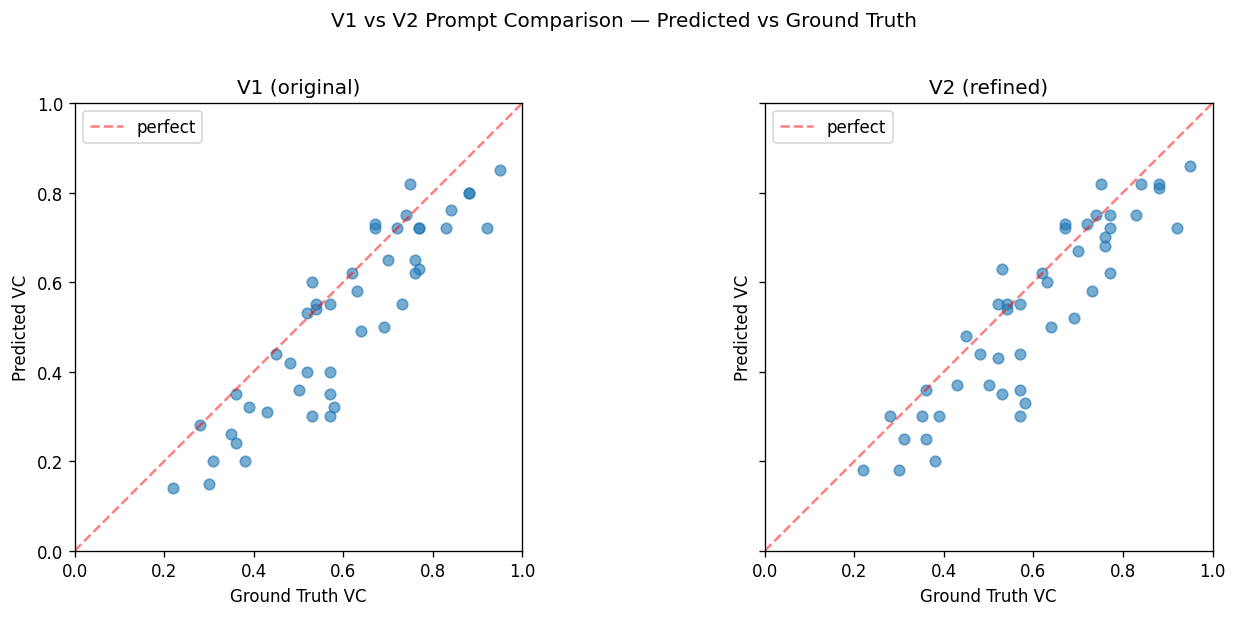

In [14]:
# ── Scatter: V1 vs V2 side-by-side ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, pv, label in zip(axes, [pred_vc, pred_vc2], ['V1 (original)', 'V2 (refined)']):
    ax.scatter(gt_vc if label.startswith('V1') else gt_vc2, pv, alpha=0.6, s=40)
    ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='perfect')
    ax.set_xlabel('Ground Truth VC')
    ax.set_ylabel('Predicted VC')
    ax.set_title(label)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend()
    ax.set_aspect('equal')

fig.suptitle('V1 vs V2 Prompt Comparison — Predicted vs Ground Truth', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# ── Per-image improvement: error reduction ──
df_compare = df[['imageName', 'NormalizedVC', 'vc_score']].rename(columns={'vc_score': 'v1_pred'})
df_compare = df_compare.merge(
    df_v2[['imageName', 'vc_score']].rename(columns={'vc_score': 'v2_pred'}),
    on='imageName'
)
df_compare['v1_error'] = df_compare['v1_pred'] - df_compare['NormalizedVC']
df_compare['v2_error'] = df_compare['v2_pred'] - df_compare['NormalizedVC']
df_compare['abs_improvement'] = df_compare['v1_error'].abs() - df_compare['v2_error'].abs()

improved = (df_compare['abs_improvement'] > 0).sum()
worsened = (df_compare['abs_improvement'] < 0).sum()
same = (df_compare['abs_improvement'] == 0).sum()
print(f'Improved: {improved}, Worsened: {worsened}, Same: {same}')
print(f'Mean |error| reduction: {df_compare["abs_improvement"].mean():.4f}')

# Top improvements and regressions
print(f'\nTop 5 improvements:')
top = df_compare.nlargest(5, 'abs_improvement')[['imageName','NormalizedVC','v1_pred','v2_pred','abs_improvement']]
print(top.to_string(index=False))
print(f'\nTop 5 regressions:')
worst = df_compare.nsmallest(5, 'abs_improvement')[['imageName','NormalizedVC','v1_pred','v2_pred','abs_improvement']]
print(worst.to_string(index=False))

Improved: 28, Worsened: 8, Same: 10
Mean |error| reduction: 0.0141

Top 5 improvements:
                    imageName  NormalizedVC  v1_pred  v2_pred  abs_improvement
         InfoVisJ.2699.12.png          0.76     0.62     0.68             0.06
economist_daily_chart_165.png          0.43     0.31     0.37             0.06
                   vis734.png          0.84     0.76     0.82             0.06
                   whoJ44.png          0.31     0.20     0.25             0.05
economist_daily_chart_153.png          0.53     0.30     0.35             0.05

Top 5 regressions:
           imageName  NormalizedVC  v1_pred  v2_pred  abs_improvement
InfoVisJ.1236.13.png          0.53     0.60     0.63            -0.03
   InfoVisC.73.6.png          0.39     0.32     0.30            -0.02
    VASTJ.2908.2.png          0.52     0.53     0.55            -0.02
        whoO06_2.png          0.45     0.44     0.48            -0.02
        whoQ50_2.png          0.28     0.28     0.30            -0.0

## V1 vs V2 vs V3 Comparison

In [16]:
# ── Load V3 scores and compare all versions ──
pred_v3 = pd.read_csv('../vc_api_46gt_v3/vc_scores.csv')
df_v3 = gt.merge(pred_v3, left_on='imageName', right_on='filename', how='inner')
print(f'V3 matched: {len(df_v3)} / {len(gt)} images')

gt_vc3 = df_v3['NormalizedVC'].values
pred_vc3 = df_v3['vc_score'].values

r3, p3_ = pearsonr(gt_vc3, pred_vc3)
rho3, rp3 = spearmanr(gt_vc3, pred_vc3)
mae3 = np.mean(np.abs(pred_vc3 - gt_vc3))
rmse3 = np.sqrt(np.mean((pred_vc3 - gt_vc3)**2))
bias3 = np.mean(pred_vc3 - gt_vc3)

print(f'\n{"Metric":<18} {"V1":>8} {"V2":>8} {"V3":>8} {"Best":>6}')
print('-' * 52)
for label, v1v, v2v, v3v in [
    ('Pearson r',  pearson_r, r2, r3),
    ('Spearman ρ', spearman_r, rho2, rho3),
    ('MAE',        mae, mae2, mae3),
    ('RMSE',       rmse, rmse2, rmse3),
    ('Bias',       bias, bias2, bias3),
]:
    vals_list = [('V1',v1v), ('V2',v2v), ('V3',v3v)]
    if label in ('MAE','RMSE','Bias'):
        best = min(vals_list, key=lambda x: abs(x[1]))[0]
    else:
        best = max(vals_list, key=lambda x: x[1])[0]
    print(f'{label:<18} {v1v:>8.3f} {v2v:>8.3f} {v3v:>8.3f} {best:>6}')

print(f'\nV1 pred range: [{pred_vc.min():.2f}, {pred_vc.max():.2f}]')
print(f'V2 pred range: [{pred_vc2.min():.2f}, {pred_vc2.max():.2f}]')
print(f'V3 pred range: [{pred_vc3.min():.2f}, {pred_vc3.max():.2f}]')
print(f'GT range:       [{gt_vc.min():.2f}, {gt_vc.max():.2f}]')

V3 matched: 46 / 46 images

Metric                   V1       V2       V3   Best
----------------------------------------------------
Pearson r             0.904    0.905    0.912     V3
Spearman ρ            0.891    0.889    0.907     V3
MAE                   0.097    0.083    0.074     V3
RMSE                  0.121    0.107    0.089     V3
Bias                 -0.085   -0.066   -0.025     V3

V1 pred range: [0.14, 0.85]
V2 pred range: [0.18, 0.86]
V3 pred range: [0.18, 0.88]
GT range:       [0.22, 0.95]


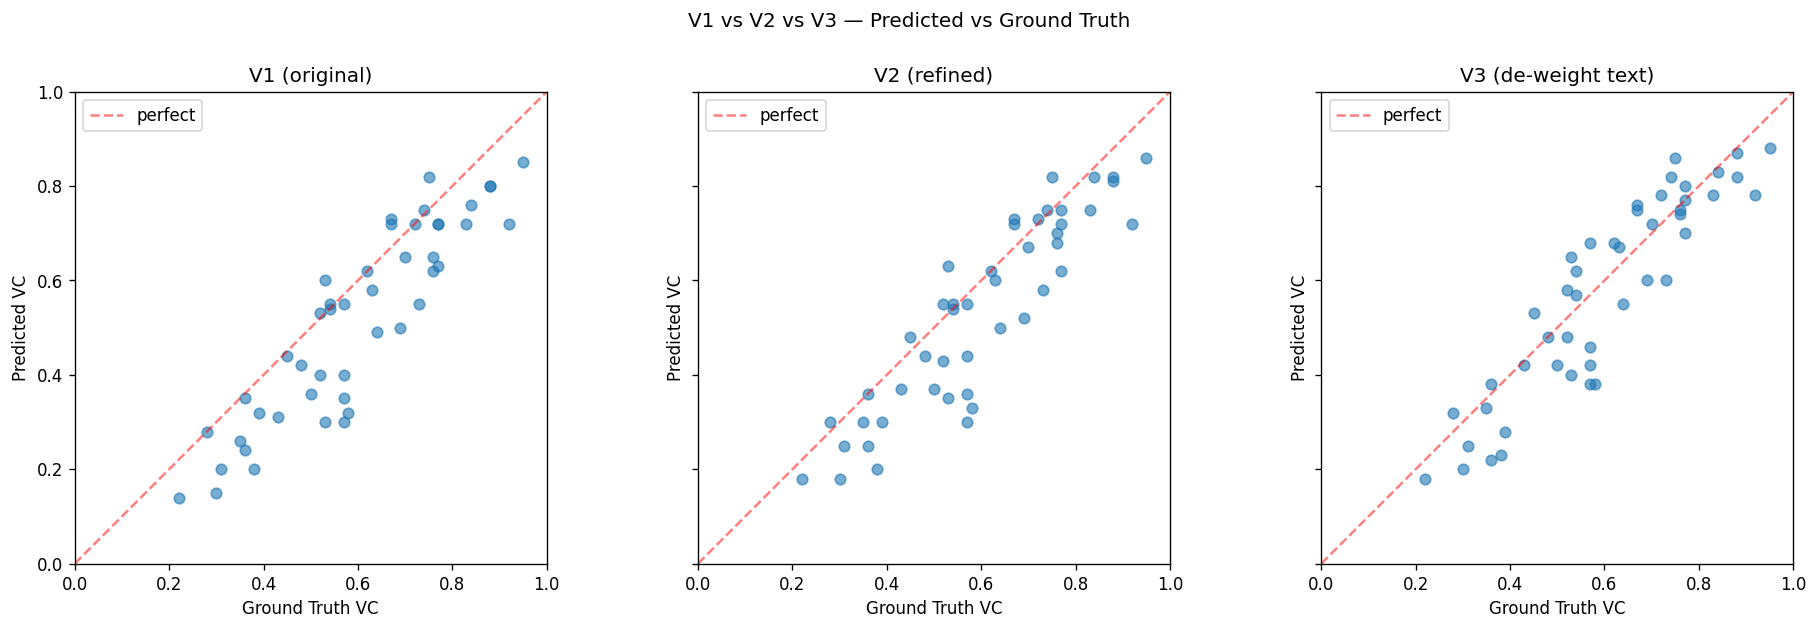

In [17]:
# ── Scatter: V1 vs V2 vs V3 side-by-side ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, pv, gv, label in zip(axes,
    [pred_vc, pred_vc2, pred_vc3],
    [gt_vc, gt_vc2, gt_vc3],
    ['V1 (original)', 'V2 (refined)', 'V3 (de-weight text)']):
    ax.scatter(gv, pv, alpha=0.6, s=40)
    ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='perfect')
    ax.set_xlabel('Ground Truth VC')
    ax.set_ylabel('Predicted VC')
    ax.set_title(label)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend()
    ax.set_aspect('equal')

fig.suptitle('V1 vs V2 vs V3 — Predicted vs Ground Truth', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# ── Per-image: V3 vs V2 improvement ──
df_c3 = df[['imageName', 'NormalizedVC', 'vc_score']].rename(columns={'vc_score': 'v1_pred'})
df_c3 = df_c3.merge(df_v2[['imageName', 'vc_score']].rename(columns={'vc_score': 'v2_pred'}), on='imageName')
df_c3 = df_c3.merge(df_v3[['imageName', 'vc_score']].rename(columns={'vc_score': 'v3_pred'}), on='imageName')
df_c3['v1_err'] = (df_c3['v1_pred'] - df_c3['NormalizedVC']).abs()
df_c3['v2_err'] = (df_c3['v2_pred'] - df_c3['NormalizedVC']).abs()
df_c3['v3_err'] = (df_c3['v3_pred'] - df_c3['NormalizedVC']).abs()

# V3 vs V1 improvement
v3_better = (df_c3['v3_err'] < df_c3['v1_err']).sum()
v3_worse = (df_c3['v3_err'] > df_c3['v1_err']).sum()
v3_same = (df_c3['v3_err'] == df_c3['v1_err']).sum()
print(f'V3 vs V1: {v3_better} improved, {v3_worse} worsened, {v3_same} same')
print(f'V3 vs V2: {(df_c3["v3_err"] < df_c3["v2_err"]).sum()} improved, '
      f'{(df_c3["v3_err"] > df_c3["v2_err"]).sum()} worsened, '
      f'{(df_c3["v3_err"] == df_c3["v2_err"]).sum()} same')

# Show the previous worst outliers
outliers = ['InfoVisJ.1558.11(3).png', 'VisJ.1515.12.png', 'economist_daily_chart_153.png',
            'SciVisJ.822.18.png', 'InfoVisC.65.5(2).png']
print(f'\nPrevious worst outliers:')
cols = ['imageName','NormalizedVC','v1_pred','v2_pred','v3_pred']
print(df_c3[df_c3['imageName'].isin(outliers)][cols].to_string(index=False))

V3 vs V1: 30 improved, 16 worsened, 0 same
V3 vs V2: 27 improved, 17 worsened, 2 same

Previous worst outliers:
                    imageName  NormalizedVC  v1_pred  v2_pred  v3_pred
      InfoVisJ.1558.11(3).png          0.57     0.30     0.30     0.38
             VisJ.1515.12.png          0.58     0.32     0.33     0.38
economist_daily_chart_153.png          0.53     0.30     0.35     0.40
           SciVisJ.822.18.png          0.57     0.35     0.36     0.42
         InfoVisC.65.5(2).png          0.92     0.72     0.72     0.78
